## PriceSage — Why Does Our Model Fail on New Listings?
### A Progressive Study of Bias, Variance, and Regularisation

---

### The Scenario

You've just joined PriceSage, a startup that predicts house prices for real estate agents.

Your manager sends you a message:

> *"We shipped the first model last week. It looked great on training data.  
> On real new listings it's terrible. The senior engineer says we need to 'regularise'.  
> What does that even mean? Fix it."*

This notebook is about diagnosing that failure, understanding why it happens,  
and systematically fixing it — using the **California Housing** dataset.

You will build six models. Each one fixes a flaw in the previous one.  
By the end, you'll know exactly how to choose between Ridge and Lasso, and why it matters.

---

### 📖 Background Reading — Start Here
[Bias–Variance Tradeoff — StatQuest (YouTube)](https://www.youtube.com/watch?v=EuBBz3bI-aA)  
[Scott Fortmann-Roe: Understanding the Tradeoff](https://scott.fortmann-roe.com/docs/BiasVariance.html)  
[Learning Curves — sklearn docs](https://scikit-learn.org/stable/modules/learning_curve.html)  
[Regularisation — Towards Data Science](https://towardsdatascience.com/regularization-in-machine-learning-76441ddcf99a)  

---

### Notebook Breakdown

| Part | Story Beat | Key Concept |
|---|---|---|
| A | Understand the data | EDA, feature relationships |
| B | Build the simplest model — watch it underfit | Linear regression, residual diagnosis |
| C | Make it more complex — watch it overfit | Polynomial regression, learning curves |
| D | Understand *why* this happens | Bias–variance tradeoff (conceptual) |
| E | Fix overfitting with Ridge | L2 regularisation, cross-validation |
| F | Try Lasso — earn sparsity | L1 regularisation, feature selection, final comparison |


### ⚙️ Setup — Run this first

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import warnings
warnings.filterwarnings('ignore')

from sklearn.datasets import fetch_california_housing
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.linear_model import (LinearRegression, Ridge, Lasso,
                                   RidgeCV, LassoCV)
from sklearn.pipeline import Pipeline
from sklearn.model_selection import (train_test_split, cross_val_score,
                                      learning_curve, validation_curve, KFold)
from sklearn.metrics import mean_squared_error, r2_score
import seaborn as sns

np.random.seed(42)
plt.rcParams.update({
    'figure.dpi': 110,
    'font.size': 11,
    'axes.spines.top': False,
    'axes.spines.right': False,
})

# ── Load and clean data ────────────────────────────────────────────────────────
housing = fetch_california_housing(as_frame=True)
df = housing.frame.copy()
df = df[df['MedHouseVal'] < 5.0].reset_index(drop=True)   # remove survey cap artefact

FEATURES   = housing.feature_names
X_full     = df[FEATURES].values
y_full     = df['MedHouseVal'].values

X_tr, X_te, y_tr, y_te = train_test_split(
    X_full, y_full, test_size=0.2, random_state=42)

print("Setup complete.")
print(f"  Dataset  : California Housing ({len(df):,} rows, {len(FEATURES)} features)")
print(f"  Target   : MedHouseVal — median house value in $100,000s")
print(f"  Train    : {len(X_tr):,} rows  |  Test : {len(X_te):,} rows")


Setup complete.
  Dataset  : California Housing (19,648 rows, 8 features)
  Target   : MedHouseVal — median house value in $100,000s
  Train    : 15,718 rows  |  Test : 3,930 rows


---
## Part A — Understanding the Data

> Before building anything, your first job is to understand what the data looks like, what the target behaves like, and which features are likely to matter.

📖 [California Housing Dataset — sklearn reference](https://scikit-learn.org/stable/datasets/real_world.html#california-housing-dataset)

### What's in the dataset?

Each row is a census block group from the 1990 California census (~600–3,000 people per group).


In [2]:
# ── A1: Dataset summary ────────────────────────────────────────────────────────
print("=" * 55)
print("  California Housing — Dataset Summary")
print("=" * 55)
print(f"  Rows      : {len(df):,}")
print(f"  Features  : {len(FEATURES)}  → {list(FEATURES)}")
print(f"  Target    : MedHouseVal  range ${y_full.min():.2f}–${y_full.max():.2f} (x$100k)")


  California Housing — Dataset Summary
  Rows      : 19,648
  Features  : 8  → ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']
  Target    : MedHouseVal  range $0.15–$4.99 (x$100k)


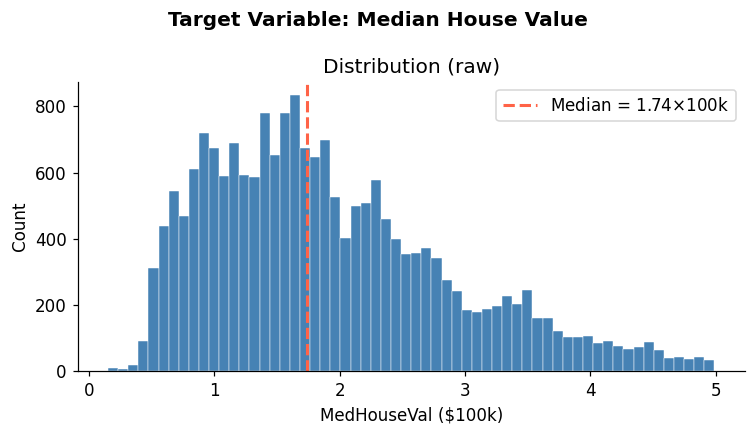

In [3]:
# ── A2: Target distribution ────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 1, figsize=(7, 4))
fig.suptitle('Target Variable: Median House Value', fontweight='bold')

axes.hist(df['MedHouseVal'], bins=60, color='steelblue', edgecolor='white', lw=0.3)
axes.axvline(df['MedHouseVal'].median(), color='tomato', lw=2, ls='--', label=f"Median = ${df['MedHouseVal'].median():.2f}×$100k")
axes.set(xlabel='MedHouseVal ($100k)', ylabel='Count', title='Distribution (raw)')
axes.legend()

plt.tight_layout()
plt.show()

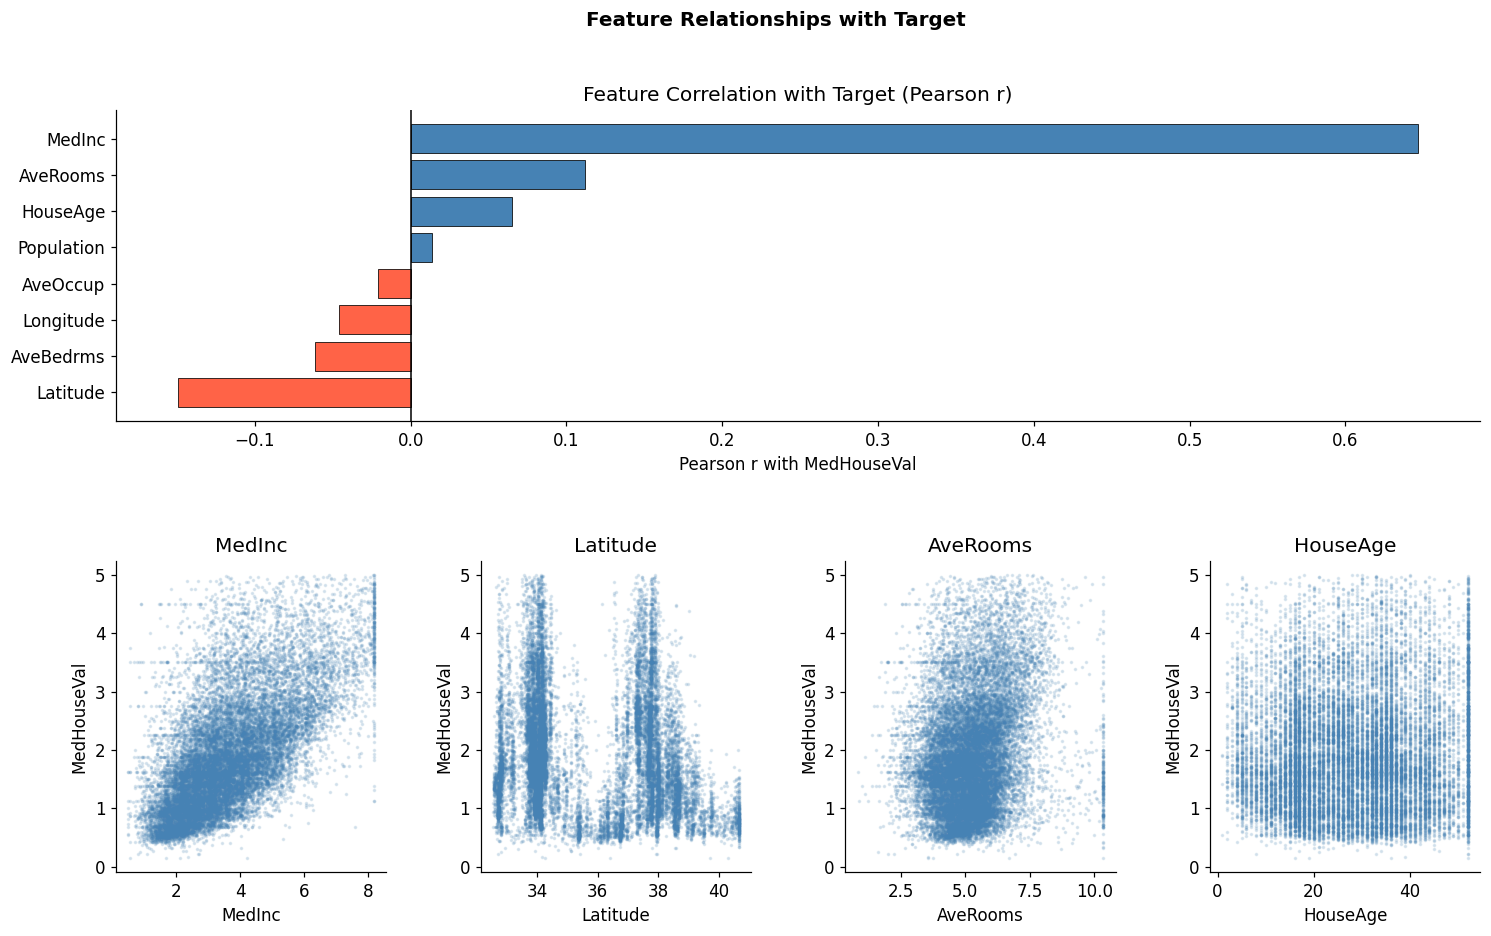

In [4]:
# ── A3: Feature correlations and scatter plots ────────────────────────────────
fig = plt.figure(figsize=(16, 9))
gs  = gridspec.GridSpec(2, 4, figure=fig, hspace=0.45, wspace=0.35)
fig.suptitle('Feature Relationships with Target', fontsize=13, fontweight='bold')

# Correlation bar
ax_corr = fig.add_subplot(gs[0, :])
target_corr = df.corr()['MedHouseVal'].drop('MedHouseVal').sort_values()
colors = ['tomato' if c < 0 else 'steelblue' for c in target_corr]
ax_corr.barh(target_corr.index, target_corr.values, color=colors,
             edgecolor='k', lw=0.5)
ax_corr.axvline(0, color='k', lw=1)
ax_corr.set(xlabel='Pearson r with MedHouseVal',
            title='Feature Correlation with Target (Pearson r)')

# Scatter plots: top 4 features
top_feats = ['MedInc', 'Latitude', 'AveRooms', 'HouseAge']
for i, feat in enumerate(top_feats):
    ax = fig.add_subplot(gs[1, i])
    x_clipped = df[feat].clip(upper=df[feat].quantile(0.99))
    ax.scatter(x_clipped, df['MedHouseVal'], s=2, alpha=0.15, color='steelblue')
    ax.set(xlabel=feat, ylabel='MedHouseVal', title=f'{feat}')

plt.show()


#### 📝 Part A — Conceptual Questions

**Q1.** `MedInc` has the strongest correlation with house value.  
But correlation only captures *linear* relationships.  
Look at the scatter plot for `MedInc`. Does the relationship look perfectly linear?  
What does this suggest about whether a linear model will be sufficient?


**A1.** 
No, the relationship does not look perfectly linear.The scatter indicates a strong but not perfectly linear trend: there is curvature changing spread and signs of saturation at high income levels. So a purely linear model will capture only the broad direction and miss nonlinear structure. This suggests linear regression alone is likely to underfit and feature expansion plus regularisation is more suitable.

What this suggests:

A linear model may not be sufficient to capture the relationship between MedInc and house value.
it cannot capture the curved relationship and the increasing variance in house values as income increases.
This suggests that we may need to consider more complex models that can capture non-linear relationships.




---
## Part B — The Simplest Model: Linear Regression

> Your first instinct is to keep it simple. You build a linear regression on all 8 features and ship it. The test error is acceptable — but residual patterns tell a different story.


### What Linear Regression Assumes

Linear regression fits:
$$\hat{y} = w_0 + w_1 x_1 + w_2 x_2 + \cdots + w_8 x_8$$

This assumes the relationship between features and house value is **purely additive and linear**. If the true relationship is curved or involves interactions, the model is structurally incapable of capturing it — no amount of more data will fix this. This is called underfitting.


In [5]:
# ── B1: Fit baseline linear regression ────────────────────────────────────────

scaler_base = StandardScaler()
X_tr_s = scaler_base.fit_transform(X_tr)
X_te_s = scaler_base.transform(X_te)

lr = LinearRegression().fit(X_tr_s, y_tr)

y_pred_tr = lr.predict(X_tr_s)
y_pred_te = lr.predict(X_te_s)

tr_mse = mean_squared_error(y_tr, y_pred_tr)
te_mse = mean_squared_error(y_te, y_pred_te)
tr_r2  = r2_score(y_tr, y_pred_tr)
te_r2  = r2_score(y_te, y_pred_te)

print("=== Baseline: Linear Regression (all 8 features) ===")
print(f"  Train MSE : {tr_mse:.4f}   Train R² : {tr_r2:.4f}")
print(f"  Test  MSE : {te_mse:.4f}   Test  R² : {te_r2:.4f}")
print(f"  Gap (Test–Train MSE): {te_mse - tr_mse:.4f}")


=== Baseline: Linear Regression (all 8 features) ===
  Train MSE : 0.3985   Train R² : 0.5756
  Test  MSE : 0.4133   Test  R² : 0.5689
  Gap (Test–Train MSE): 0.0147


Setup complete.
  Dataset  : California Housing (19,648 rows, 8 features)
  Target   : MedHouseVal — median house value in $100,000s
  Train    : 15,718 rows  |  Test : 3,930 rows


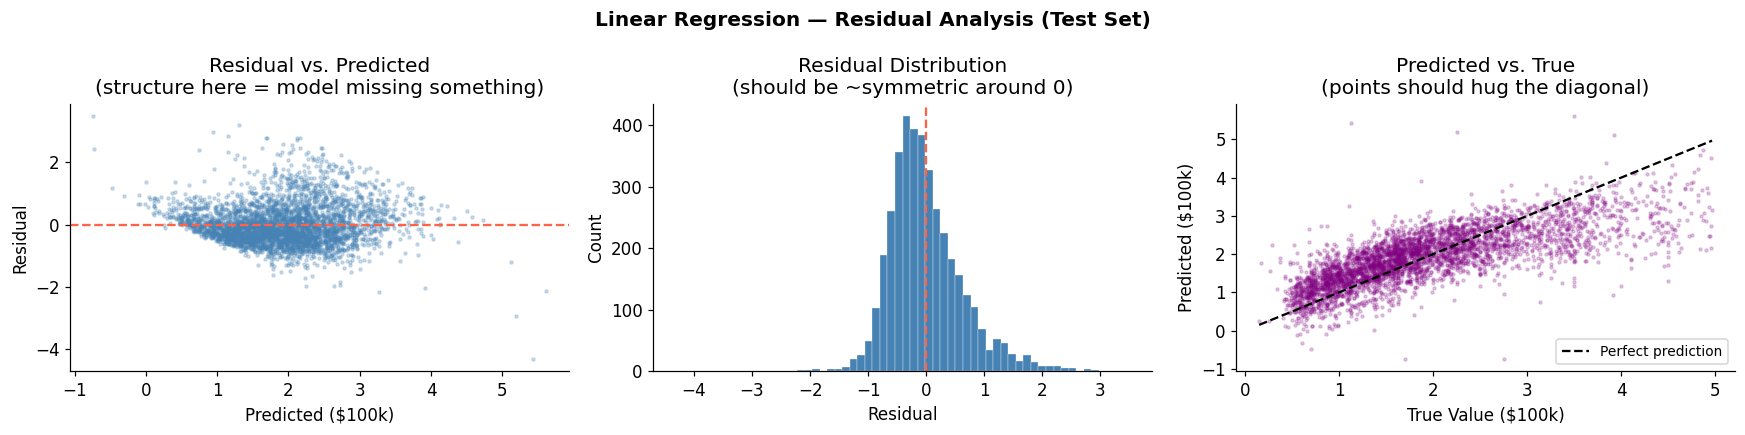

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import warnings
warnings.filterwarnings('ignore')

from sklearn.datasets import fetch_california_housing
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.linear_model import (LinearRegression, Ridge, Lasso,
                                   RidgeCV, LassoCV)
from sklearn.pipeline import Pipeline
from sklearn.model_selection import (train_test_split, cross_val_score,
                                      learning_curve, validation_curve, KFold)
from sklearn.metrics import mean_squared_error, r2_score
import seaborn as sns

np.random.seed(42)
plt.rcParams.update({
    'figure.dpi': 110,
    'font.size': 11,
    'axes.spines.top': False,
    'axes.spines.right': False,
})

# __ Load and clean data ________________________________________________________
housing = fetch_california_housing(as_frame=True)
df = housing.frame.copy()
df = df[df['MedHouseVal'] < 5.0].reset_index(drop=True)   # remove survey cap artefact

FEATURES   = housing.feature_names
X_full     = df[FEATURES].values
y_full     = df['MedHouseVal'].values

X_tr, X_te, y_tr, y_te = train_test_split(
    X_full, y_full, test_size=0.2, random_state=42)

print("Setup complete.")
print(f"  Dataset  : California Housing ({len(df):,} rows, {len(FEATURES)} features)")
print(f"  Target   : MedHouseVal — median house value in $100,000s")
print(f"  Train    : {len(X_tr):,} rows  |  Test : {len(X_te):,} rows")
# __ B2: Residual diagnosis ____________________________________________________
# A well-fitted model should show structureless, zero-centred residuals.
# Patterns in residuals = the model is missing something.

residuals_te = y_te - y_pred_te

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
fig.suptitle('Linear Regression — Residual Analysis (Test Set)', fontweight='bold')

# Residual vs fitted
axes[0].scatter(y_pred_te, residuals_te, s=4, alpha=0.25, color='steelblue')
axes[0].axhline(0, color='tomato', lw=1.5, ls='--')
axes[0].set(xlabel='Predicted ($100k)', ylabel='Residual',
            title='Residual vs. Predicted\n(structure here = model missing something)')

# Residual histogram
axes[1].hist(residuals_te, bins=60, color='steelblue', edgecolor='white', lw=0.2)
axes[1].axvline(0, color='tomato', lw=1.5, ls='--')
axes[1].set(xlabel='Residual', ylabel='Count',
            title='Residual Distribution\n(should be ~symmetric around 0)')

# Predicted vs true
axes[2].scatter(y_te, y_pred_te, s=4, alpha=0.2, color='purple')
lims = [y_te.min(), y_te.max()]
axes[2].plot(lims, lims, 'k--', lw=1.5, label='Perfect prediction')
axes[2].set(xlabel='True Value ($100k)', ylabel='Predicted ($100k)',
            title='Predicted vs. True\n(points should hug the diagonal)')
axes[2].legend(fontsize=9)

plt.tight_layout()
plt.show()

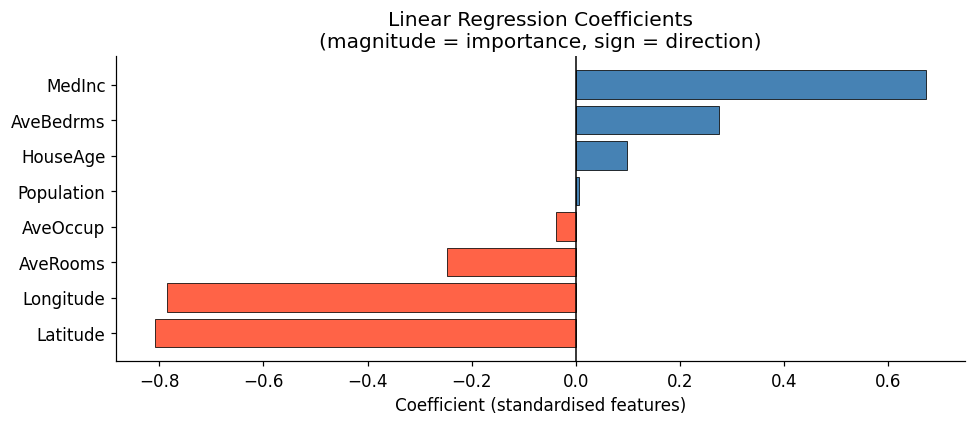

Key observation: MedInc dominates. Latitude and Longitude are strongly negative.
But a linear model treats these as independent additive effects —
it cannot learn that location interacts with income to determine price.


In [7]:
# ── B3: Coefficient plot — what did the model learn? ─────────────────────────

fig, ax = plt.subplots(figsize=(9, 4))
coef_df = pd.Series(lr.coef_, index=FEATURES).sort_values()
colors  = ['tomato' if c < 0 else 'steelblue' for c in coef_df]
ax.barh(coef_df.index, coef_df.values, color=colors, edgecolor='k', lw=0.5)
ax.axvline(0, color='k', lw=1)
ax.set(xlabel='Coefficient (standardised features)',
       title='Linear Regression Coefficients\n(magnitude = importance, sign = direction)')
plt.tight_layout()
plt.show()

print("Key observation: MedInc dominates. Latitude and Longitude are strongly negative.")
print("But a linear model treats these as independent additive effects —")
print("it cannot learn that location interacts with income to determine price.")


#### 📝 Part B — Conceptual Questions

**Q2.** Look at the *Residual vs. Predicted* plot.  
Is there a visible pattern (curve, fan shape, clustering)?  
What does a pattern in residuals tell you about the model's assumptions?


**A2.** Yes there is visible structure rather than random scatter around zero. Residual spread is not constant and there are regions where errors are systematically positive or negative. A pattern in residuals means the model assumptions are violated: the linear/additive form is missing nonlinearity and possibly interactions and error variance may be heteroscedastic. Ideally residuals should look like noise with no shape.

**Q3.** The train and test R² are relatively close to each other.  
Does this mean the model is good? What specific failure mode does close train/test error *not* rule out?  
*(Hint: Think about what "close" means when both numbers are low.)*


**A3.** Not necessarily. Close train/test performance only tells us the model generalises similarly on both sets; it does **not** guarantee high absolute performance. If both errors are high (or both R² values are modest) the model can still be underfitting. So close train/test values rule out severe overfitting but they do not rule out high bias.


---
## Part C — Adding Complexity: Polynomial Regression & Learning Curves

> The linear model underfits. You add polynomial features to capture nonlinear relationships. It works — until it doesn't. You need a diagnostic tool to tell you when the model crosses from underfitting into overfitting. That tool is the learning curve.

📖 [Learning Curves — sklearn docs](https://scikit-learn.org/stable/modules/learning_curve.html)  

### What Polynomial Features Do

A degree-2 polynomial on 8 features creates interaction terms like:
$$x_1^2,\; x_1 x_2,\; x_2^2,\; \ldots$$

- Degree 1: 8 features (original)
- Degree 2: 44 features
- Degree 3: 165 features

As degree grows, the model can fit more complex patterns — but also memorise noise.

### Reading a Learning Curve

A learning curve plots **training error and validation error as a function of training set size**.

| Pattern | Diagnosis |
|---|---|
| Large gap between train and val curves | **High variance (overfitting)** — adding more data will help |
| Both curves high and converged | **High bias (underfitting)** — need a more complex model |
| Both curves low and converged | **Good generalisation** |


In [8]:
# ── C1: Compare polynomial degrees — train vs. test error ────────────────────

DEGREES = [1, 2, 3, 4]
poly_results = {}

print(f"{'Degree':>8}  {'# Features':>12}  {'Train MSE':>10}  {'Test MSE':>10}  {'Test R²':>10}")
print("-" * 60)

for d in DEGREES:
    pipe = Pipeline([
        ('poly',   PolynomialFeatures(degree=d, include_bias=False)),
        ('scaler', StandardScaler()),
        ('lr',     LinearRegression())
    ])
    pipe.fit(X_tr, y_tr)

    n_feats = pipe.named_steps['poly'].n_output_features_
    tr_mse  = mean_squared_error(y_tr, pipe.predict(X_tr))
    te_mse  = mean_squared_error(y_te, pipe.predict(X_te))
    te_r2   = r2_score(y_te, pipe.predict(X_te))

    poly_results[d] = {
        'pipe': pipe, 'n_features': n_feats,
        'train_mse': tr_mse, 'test_mse': te_mse, 'test_r2': te_r2
    }
    print(f"{d:>8}  {n_feats:>12,}  {tr_mse:>10.4f}  {te_mse:>10.4f}  {te_r2:>10.4f}")


  Degree    # Features   Train MSE    Test MSE     Test R²
------------------------------------------------------------
       1             8      0.3985      0.4133      0.5689
       2            44      0.3230      0.3590      0.6255
       3           164      0.2753      1.2081     -0.2601
       4           494      0.2298    341.1280   -354.8132


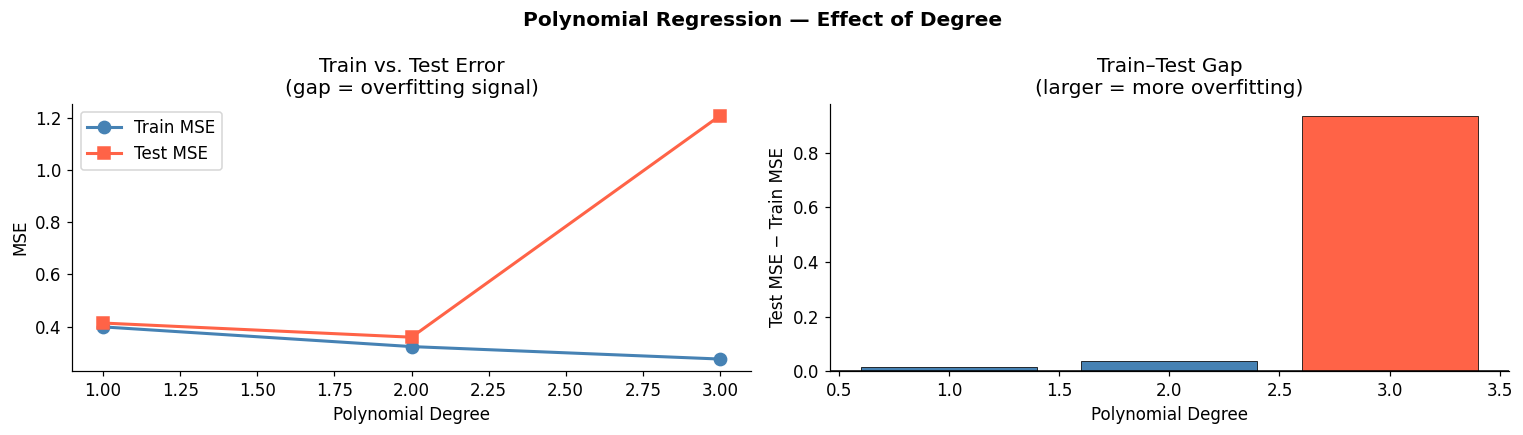

In [9]:
# ── C2: Train vs. test error vs. degree ──────────────────────────────────────
DEGREES = [1, 2, 3]
tr_errs = [poly_results[d]['train_mse'] for d in DEGREES]
te_errs = [poly_results[d]['test_mse']  for d in DEGREES]
gaps    = [te - tr for tr, te in zip(tr_errs, te_errs)]

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
fig.suptitle('Polynomial Regression — Effect of Degree', fontweight='bold')

axes[0].plot(DEGREES, tr_errs, 'o-', color='steelblue', lw=2, ms=8, label='Train MSE')
axes[0].plot(DEGREES, te_errs, 's-', color='tomato',    lw=2, ms=8, label='Test MSE')
axes[0].set(xlabel='Polynomial Degree', ylabel='MSE',
            title='Train vs. Test Error\n(gap = overfitting signal)')
axes[0].legend()

axes[1].bar(DEGREES, gaps, color=['steelblue' if g < 0.05 else 'tomato' for g in gaps],
            edgecolor='k', lw=0.5)
axes[1].axhline(0, color='k', lw=1)
axes[1].set(xlabel='Polynomial Degree', ylabel='Test MSE − Train MSE',
            title='Train–Test Gap\n(larger = more overfitting)')

plt.tight_layout()
plt.show()

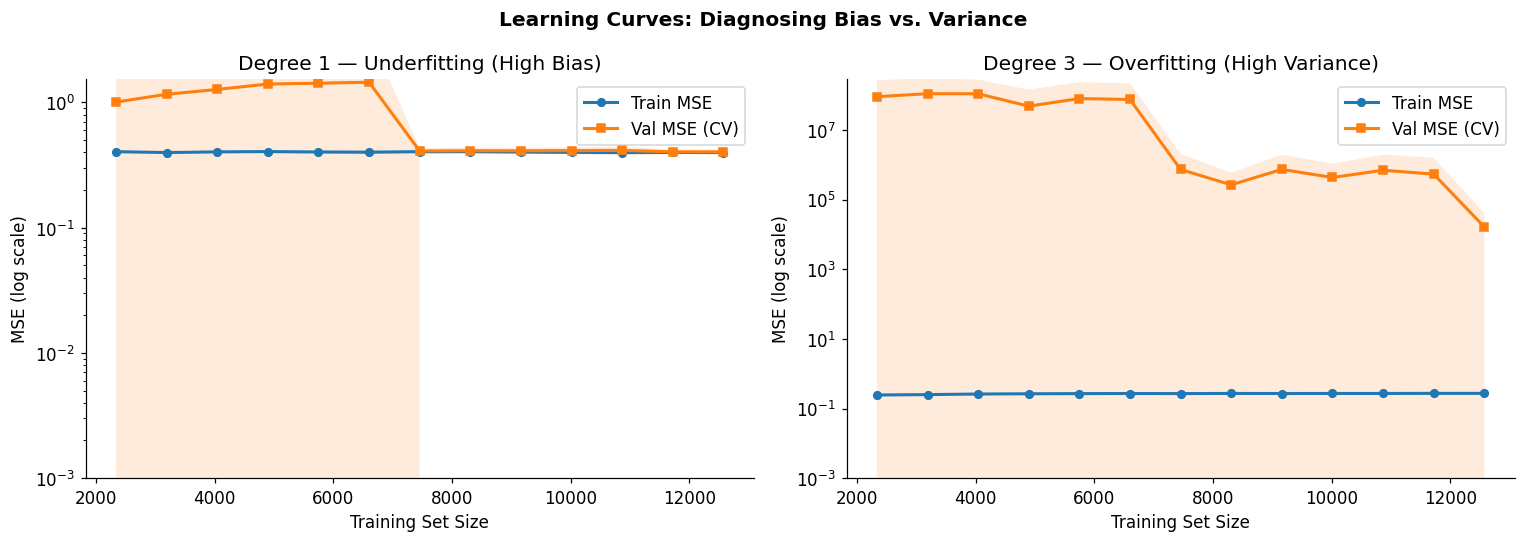

In [10]:
# ── C3: Learning curves for degree 1 (underfit) and degree 3 (overfit) ───────

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Learning Curves: Diagnosing Bias vs. Variance', fontweight='bold')

TRAIN_SIZES = np.linspace(0.05, 1.0, 15)

for ax, d, label in zip(
        axes,
        [1, 3],
        ['Degree 1 — Underfitting (High Bias)',
         'Degree 3 — Overfitting (High Variance)']):

    pipe = Pipeline([
        ('poly',   PolynomialFeatures(degree=d, include_bias=False)),
        ('scaler', StandardScaler()),
        ('lr',     LinearRegression())
    ])

    train_sz, train_sc, val_sc = learning_curve(
        pipe, X_tr, y_tr,
        train_sizes=TRAIN_SIZES,
        scoring='neg_mean_squared_error',
        cv=5, n_jobs=-1
    )

    train_mse = -train_sc.mean(axis=1)
    val_mse   = -val_sc.mean(axis=1)
    train_std = train_sc.std(axis=1)
    val_std   = val_sc.std(axis=1)

    # ───── Remove unstable very small training sizes ─────
    train_sz  = train_sz[2:]
    train_mse = train_mse[2:]
    val_mse   = val_mse[2:]
    train_std = train_std[2:]
    val_std   = val_std[2:]

    # Optional: log scale helps visual clarity
    ax.set_yscale('log')

    ax.plot(train_sz, train_mse, 'o-', lw=2, ms=5, label='Train MSE')
    ax.plot(train_sz, val_mse,   's-', lw=2, ms=5, label='Val MSE (CV)')

    ax.fill_between(train_sz,
                    train_mse - train_std,
                    train_mse + train_std,
                    alpha=0.15)
    ax.set_ylim(bottom=1e-3)  # log scale needs positive lower bound

    ax.fill_between(train_sz,
                    val_mse - val_std,
                    val_mse + val_std,
                    alpha=0.15)
    ax.set_ylim(bottom=1e-3)  # log scale needs positive lower bound

    ax.set(xlabel='Training Set Size',
           ylabel='MSE (log scale)',
           title=label)

    ax.legend()

plt.tight_layout()
plt.show()

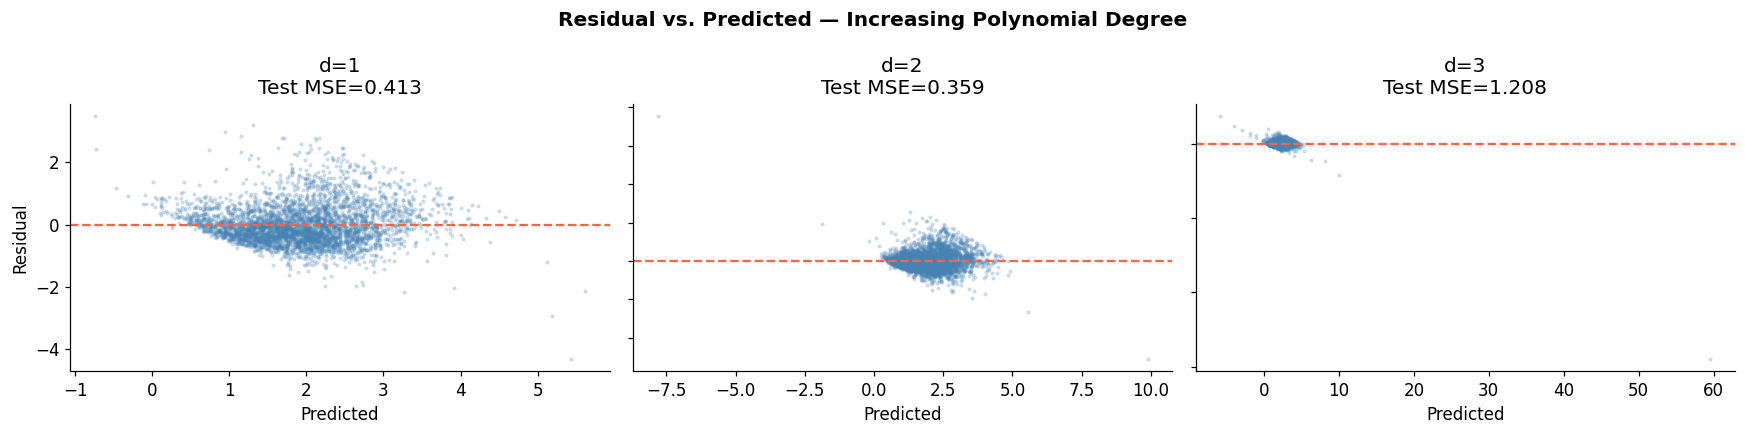

In [11]:
# ── C4: Residual comparison across degrees ────────────────────────────────────

fig, axes = plt.subplots(1, len(DEGREES), figsize=(16, 4), sharey=False)
fig.suptitle('Residual vs. Predicted — Increasing Polynomial Degree', fontweight='bold')

for ax, d in zip(axes, DEGREES):
    pipe   = poly_results[d]['pipe']
    resid  = y_te - pipe.predict(X_te)
    y_pred = pipe.predict(X_te)

    ax.scatter(y_pred, resid, s=3, alpha=0.2, color='steelblue')
    ax.axhline(0, color='tomato', lw=1.5, ls='--')
    ax.set(title=f'd={d}\nTest MSE={poly_results[d]["test_mse"]:.3f}',
           xlabel='Predicted')
    ax.label_outer()

axes[0].set_ylabel('Residual')
plt.tight_layout()
plt.show()


#### 📝 Part C — Conceptual Questions

**Q4.** In the learning curve for **degree 1**:  
What happens to the train–val gap as training size increases?  
Does adding more data fix the problem? What should you do instead?


**A4.** For degree 1 the train and validation curves get closer as sample size increases but both remain at relatively high error. That means variance is not the main issue; bias is. Adding more data alone will not fix a structurally too-simple model. The right fix is to increase model expressiveness (nonlinear features/interactions) then control complexity with regularisation if needed.

**Q5.** In the learning curve for **degree 3**:  
The validation curve is still declining at the right edge.  
What does this tell you about whether more data would help this model?  
Is more data the *only* fix needed?


**A5.** 

It indicates that model is still overfitting the training data and has not yet reached its optimal performance on the validation set.
Adding more data would likely help this model to generalise better and reduce overfitting, as it would provide more examples for the model to learn from and potentially capture the underlying patterns in the data more effectively.

No, more data is not the only fix needed. other fixes that can be considered include:
Regularisation: adding a penalty term to the loss function to discourage the model from fitting noise in the training data.
Feature selection: removing irrelevant or redundant features that may be contributing to overfitting.
Cross-validation: using techniques like k-fold cross-validation to better estimate the model's performance on unseen data and to tune hyperparameters effectively.


**Q6.** From the train-vs-test table, training error *keeps decreasing* as degree rises.  
Why does training error always decrease with more model complexity,  
even when the model is clearly overfitting?


**A6.** Training error decreases with increasing model complexity because each larger hypothesis class contains the simpler one as a special case. So the optimizer can always match or improve fit on the training set by using extra degrees of freedom. But those extra parameters may capture noise/idiosyncrasies which hurts test performance. Therefore lower training error is expected and does not imply better generalisation.

---
## Part D — Why Does This Happen? The Bias–Variance Tradeoff

> Before fixing the overfit model, you need to understand precisely what went wrong — not just that test error is high, but which component of the error is too large. This is the theoretical core.

📖 [Understanding the Bias-Variance Tradeoff](https://scott.fortmann-roe.com/docs/BiasVariance.html)  

### The Decomposition

For any model $\hat{f}$ trained on a dataset, the expected test error at a point **x** is:


Expected Test Error = Bias² + Variance + Irreducible Noise

---

### What Each Term Means

**Bias²** — *Systematic error from wrong assumptions.*  
If you retrained this exact model architecture on many different datasets of the same size, how far would the *average* prediction be from the truth?
- Degree-1 polynomial on a curved relationship → **high bias** (always wrong in the same direction)

**Variance** — *Sensitivity to the specific training data you happened to get.*  
If you swapped out your training set for a different one (same size, same distribution), how much would the model's predictions change?  
- Degree-12 polynomial → **high variance** (chases every noise point, wildly different on new data)

**Irreducible Noise (σ²)** — *Randomness in the world that no model can capture.*  
In housing: two identical houses in the same block sell for different prices (negotiation, timing, seller urgency). Even a perfect model cannot predict this component.

---

**Why you can't have both low bias and low variance:**  
A model flexible enough to capture all real patterns is also flexible enough to memorise noise.  
A model rigid enough to ignore noise is too rigid to capture real patterns.  
Regularisation shifts where you sit on this curve — it doesn't eliminate the tradeoff.

---

### How This Maps to Your Results

| What you observed | What it means |
|---|---|
| Degree-1: train ≈ val, both high | High bias, low variance — model too rigid |
| Degree-3: train << val, large gap | Low bias, high variance — model too flexible |
| Val curve still falling (degree-3) | Variance component still large; regularisation will help |
| Both curves converge at large N | Bias dominates at that stage |


#### 📝 Part D — Conceptual Questions

**Q7.** A colleague says: *"Our model overfits, so we should collect 10× more training data."*  
Using the bias–variance framework, explain when this advice is correct and when it is not.  
*(Hint: Which component does more data reduce?)*


**A7.** This advice is correct when overfitting is mainly a **variance** problem: more data stabilises parameter estimates and narrows the train-validation gap. It is not sufficient when error is dominated by **bias** (model too simple) because more data does not change model form. In bias-heavy settings we need better features or a more expressive model. In practice we diagnose with learning curves: large gap and falling validation error with more data suggests data helps; converged high curves suggest data alone will not.

---
## Part E — Fixing Overfitting: Ridge Regression (L2)

> So we know the degree-3 model has high variance. You need to constrain it without throwing away the polynomial features that captured real nonlinear patterns. Ridge regression is the tool.

📖 [Ridge Regression — StatQuest (YouTube, 6 min)](https://www.youtube.com/watch?v=Q81RR3yKn30)  

### The Ridge Objective

Instead of minimising only the fit to training data, Ridge adds a penalty:

$$\hat{w}_{\text{Ridge}} = \underset{w}{\arg\min} \; \underbrace{\|y - Xw\|^2}_{\text{Fit the data}} + \underbrace{\lambda \|w\|^2_2}_{\text{Keep weights small}}$$

**What the penalty does:**  
Large coefficients → large penalty → model penalised → coefficients shrink.  
A model with smaller coefficients is *less sensitive* to individual training points → lower variance.  
The cost: predictions are pulled slightly toward zero → small increase in bias.

**Choosing λ:**  
- λ = 0 → ordinary least squares (no regularisation)  
- λ too large → all weights → 0 → constant prediction (severe underfitting)  
- λ optimal → found by cross-validation on the training set


In [12]:
# ── E1: Pre-compute degree-3 polynomial features (used for Ridge and Lasso) ──

poly_d3   = PolynomialFeatures(degree=3, include_bias=False)
scaler_d3 = StandardScaler()

X_tr_poly = scaler_d3.fit_transform(poly_d3.fit_transform(X_tr))
X_te_poly = scaler_d3.transform(poly_d3.transform(X_te))

print(f"Degree-3 polynomial features: {X_tr_poly.shape[1]} total")
print(f"(8 original features → {X_tr_poly.shape[1]} after degree-3 expansion)")


Degree-3 polynomial features: 164 total
(8 original features → 164 after degree-3 expansion)


In [13]:
# ── E2: Ridge across a range of λ values ──────────────────────────────────────

LAMBDAS = [0, 0.001, 0.01, 0.1, 1, 10, 100, 1000]
ridge_results = {}

print(f"{'λ':>8}  {'Train MSE':>10}  {'Test MSE':>10}  {'Test R²':>10}  {'||w||²':>12}")
print("-" * 60)

for lam in LAMBDAS:
    m = Ridge(alpha=lam).fit(X_tr_poly, y_tr)
    tr_mse    = mean_squared_error(y_tr, m.predict(X_tr_poly))
    te_mse    = mean_squared_error(y_te, m.predict(X_te_poly))
    te_r2     = r2_score(y_te, m.predict(X_te_poly))
    coef_norm = np.sum(m.coef_ ** 2)
    ridge_results[lam] = {
        'model': m, 'train_mse': tr_mse, 'test_mse': te_mse,
        'test_r2': te_r2, 'coef_norm': coef_norm
    }
    print(f"{lam:>8.3f}  {tr_mse:>10.4f}  {te_mse:>10.4f}  {te_r2:>10.4f}  {coef_norm:>12.2f}")


       λ   Train MSE    Test MSE     Test R²        ||w||²
------------------------------------------------------------
   0.000      0.2753      1.2081     -0.2601  117485554.75
   0.001      0.2871      0.3665      0.6177      44332.10
   0.010      0.2930      0.4030      0.5797       3507.88
   0.100      0.2982      0.4189      0.5631        494.34
   1.000      0.3053      0.3953      0.5877         98.60
  10.000      0.3206      0.3618      0.6227         14.35
 100.000      0.3416      0.3609      0.6236          2.23
1000.000      0.3731      0.3908      0.5924          0.38


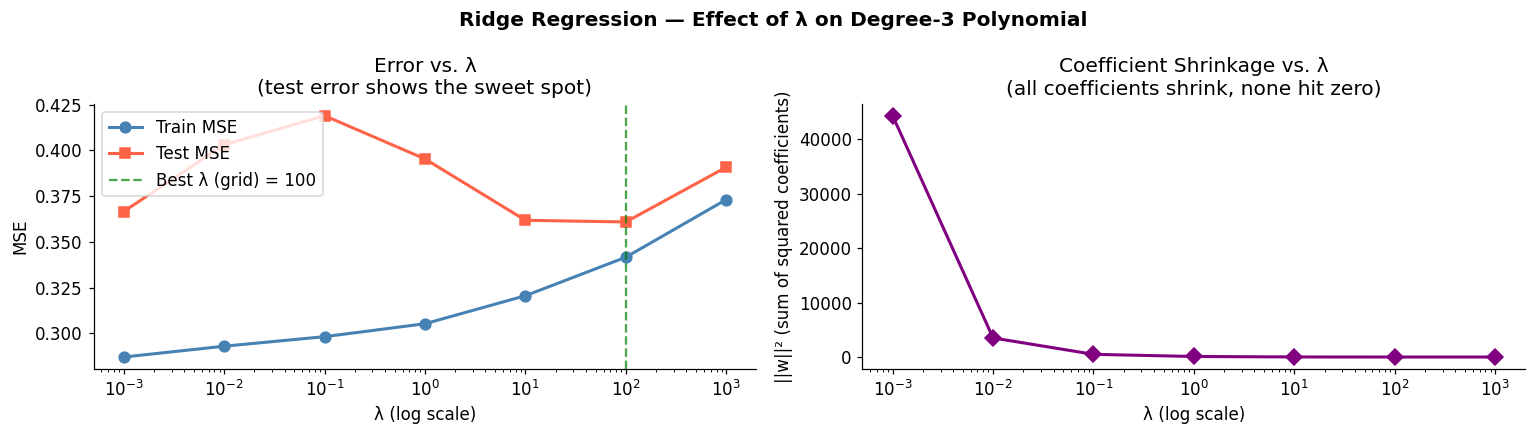

In [14]:
# ── E3: Error and coefficient shrinkage vs λ ──────────────────────────────────

lam_arr    = np.array(LAMBDAS)
tr_ridge   = [ridge_results[l]['train_mse'] for l in LAMBDAS]
te_ridge   = [ridge_results[l]['test_mse']  for l in LAMBDAS]
coef_norms = [ridge_results[l]['coef_norm'] for l in LAMBDAS]

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
fig.suptitle('Ridge Regression — Effect of λ on Degree-3 Polynomial', fontweight='bold')

ax = axes[0]
ax.semilogx(lam_arr[1:], tr_ridge[1:], 'o-', color='steelblue', lw=2, ms=7, label='Train MSE')
ax.semilogx(lam_arr[1:], te_ridge[1:], 's-', color='tomato',    lw=2, ms=7, label='Test MSE')
best_lam = min(LAMBDAS[1:], key=lambda l: ridge_results[l]['test_mse'])
ax.axvline(best_lam, color='green', ls='--', alpha=0.7,
           label=f'Best λ (grid) = {best_lam}')
ax.set(xlabel='λ (log scale)', ylabel='MSE',
       title='Error vs. λ\n(test error shows the sweet spot)')
ax.legend()

ax = axes[1]
ax.semilogx(lam_arr[1:], coef_norms[1:], 'D-', color='purple', lw=2, ms=7)
ax.set(xlabel='λ (log scale)', ylabel='||w||² (sum of squared coefficients)',
       title='Coefficient Shrinkage vs. λ\n(all coefficients shrink, none hit zero)')

plt.tight_layout()
plt.show()

In [15]:
# ── E4: RidgeCV — find optimal λ via 5-fold cross-validation ─────────────────

alphas_grid  = np.logspace(-3, 4, 80)
ridge_cv     = RidgeCV(alphas=alphas_grid, cv=5).fit(X_tr_poly, y_tr)

best_alpha   = ridge_cv.alpha_
y_pred_rcv   = ridge_cv.predict(X_te_poly)
rcv_te_mse   = mean_squared_error(y_te, y_pred_rcv)
rcv_te_r2    = r2_score(y_te, y_pred_rcv)

print(f"RidgeCV — Best λ (5-fold CV) : {best_alpha:.5f}")
print(f"          Test MSE            : {rcv_te_mse:.4f}")
print(f"          Test R²             : {rcv_te_r2:.4f}")
print()
print(f"Compare — Unregularised OLS (d=3):")
print(f"          Test MSE            : {poly_results[3]['test_mse']:.4f}")
print(f"          Test R²             : {poly_results[3]['test_r2']:.4f}")
print()
improvement = (poly_results[3]['test_mse'] - rcv_te_mse) / poly_results[3]['test_mse'] * 100
print(f"Ridge reduces test MSE by {improvement:.1f}% over unregularised degree-3 OLS.")


RidgeCV — Best λ (5-fold CV) : 2940.04806
          Test MSE            : 0.4135
          Test R²             : 0.5687

Compare — Unregularised OLS (d=3):
          Test MSE            : 1.2081
          Test R²             : -0.2601

Ridge reduces test MSE by 65.8% over unregularised degree-3 OLS.


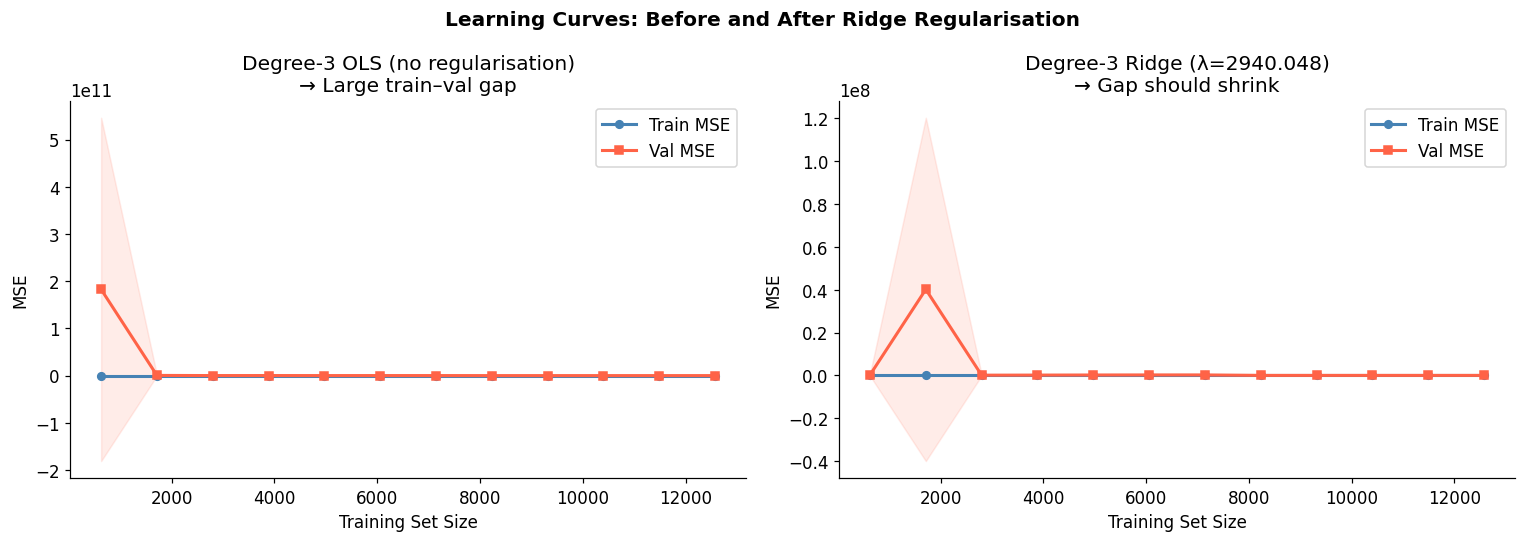

In [16]:
# ── E5: Learning curve AFTER Ridge — compare to unregularised degree-3 ───────

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Learning Curves: Before and After Ridge Regularisation', fontweight='bold')

for ax, (pipe, title) in enumerate(zip(
    [
        Pipeline([('poly', PolynomialFeatures(3, include_bias=False)),
                  ('sc',   StandardScaler()),
                  ('lr',   LinearRegression())]),
        Pipeline([('poly', PolynomialFeatures(3, include_bias=False)),
                  ('sc',   StandardScaler()),
                  ('ridge', Ridge(alpha=best_alpha))])
    ],
    ['Degree-3 OLS (no regularisation)\n→ Large train–val gap',
     f'Degree-3 Ridge (λ={best_alpha:.3f})\n→ Gap should shrink']
)):
    sz, tr_sc, val_sc = learning_curve(
        pipe, X_tr, y_tr,
        train_sizes=np.linspace(0.05, 1.0, 12),
        scoring='neg_mean_squared_error', cv=5, n_jobs=-1
    )
    tr_mse  = -tr_sc.mean(axis=1)
    val_mse = -val_sc.mean(axis=1)

    axes[ax].plot(sz, tr_mse,  'o-', color='steelblue', lw=2, ms=5, label='Train MSE')
    axes[ax].plot(sz, val_mse, 's-', color='tomato',    lw=2, ms=5, label='Val MSE')
    axes[ax].fill_between(sz,
                    tr_mse  - tr_sc.std(axis=1), tr_mse  + tr_sc.std(axis=1),
                    alpha=0.12, color='steelblue')
    axes[ax].fill_between(sz,
                    val_mse - val_sc.std(axis=1), val_mse + val_sc.std(axis=1),
                    alpha=0.12, color='tomato')
    axes[ax].set(xlabel='Training Set Size', ylabel='MSE', title=title)
    axes[ax].legend()

# for ax in axes:
#     ax.set_ylim(bottom=0)
plt.tight_layout()
plt.show()

#### 📝 Part E — Conceptual Questions

**Q8.** In the error-vs-λ plot, test MSE first decreases then increases as λ grows.  
Explain what is happening to bias and variance at each extreme  
(very small λ and very large λ).


**A8.** At very small lambda Ridge is close to unregularised OLS: bias is low but variance is high so test MSE can be elevated from overfitting. As lambda increases to a moderate range coefficient shrinkage reduces variance faster than bias rises so test MSE drops. At very large lambda coefficients are forced too close to zero the model becomes overly rigid bias dominates and both train/test errors increase (underfitting). So the U-shaped test curve reflects the bias-variance tradeoff.

**Q9.** Compare the two learning curves (before and after Ridge).  
Describe in concrete terms what changed — specifically the gap between  
train and val curves, and what this tells you about the variance of the model.


**A9.** 

before Ridge:
- The train curve is significantly lower than the validation curve, indicating a large gap between training and validation error.
- This large gap suggests that the model is overfitting the training data, meaning it is capturing noise in the training data rather than the underlying patterns, which leads to high variance.    

after Ridge:
- The train curve and validation curve are much closer together, indicating a smaller gap between training and
validation error.
- This smaller gap suggests that the model is no longer overfitting the training data and is generalising better to unseen data, which indicates a reduction in variance. The regularisation has helped to constrain the model and prevent it from fitting noise, leading to improved performance on the validation set.    


---
## Part F — Lasso, Final Comparison & Reflection

> Ridge fixed overfitting, but kept all 165 polynomial features. But the question comes: "Do we really need all of them for production?" Lasso answers that question by driving irrelevant features to exactly zero.

📖 [Lasso Regression — StatQuest (YouTube)](https://www.youtube.com/watch?v=NGf0voTMlcs)  

### The Lasso Objective

$$\hat{w}_{\text{Lasso}} = \underset{w}{\arg\min} \; \|y - Xw\|^2 + \lambda \|w\|_1$$

**The L1 penalty vs. L2:**

The only change is $\|w\|_1 = \sum |w_j|$ instead of $\|w\|_2^2 = \sum w_j^2$.  
This seemingly small difference has a large geometric consequence:

- **L2 constraint region:** a smooth sphere — optimal solutions slide along the surface,  
  coefficients shrink but almost never reach exactly zero.
- **L1 constraint region:** a diamond with corners — optimal solutions are pulled toward  
  corners, where many coefficients are **exactly zero**.

Lasso therefore simultaneously regularises and selects features.


In [17]:
# ── F1: Lasso across same λ range ─────────────────────────────────────────────

lasso_results = {}

print(f"{'λ':>8}  {'Train MSE':>10}  {'Test MSE':>10}  {'Test R²':>10}  {'Non-zero':>12}")
print("-" * 58)

for lam in LAMBDAS[1:]:
    m = Lasso(alpha=lam, max_iter=20000).fit(X_tr_poly, y_tr)
    tr_mse = mean_squared_error(y_tr, m.predict(X_tr_poly))
    te_mse = mean_squared_error(y_te, m.predict(X_te_poly))
    te_r2  = r2_score(y_te, m.predict(X_te_poly))
    n_nz   = np.sum(m.coef_ != 0)
    total  = len(m.coef_)
    lasso_results[lam] = {
        'model': m, 'train_mse': tr_mse, 'test_mse': te_mse,
        'test_r2': te_r2, 'n_nonzero': n_nz
    }
    print(f"{lam:>8.3f}  {tr_mse:>10.4f}  {te_mse:>10.4f}  {te_r2:>10.4f}  {n_nz:>5}/{total}")


       λ   Train MSE    Test MSE     Test R²      Non-zero
----------------------------------------------------------
   0.001      0.3359      0.3574      0.6272     45/164
   0.010      0.3890      0.4059      0.5767     21/164
   0.100      0.5086      0.5269      0.4505      3/164
   1.000      0.9391      0.9587     -0.0000      0/164
  10.000      0.9391      0.9587     -0.0000      0/164
 100.000      0.9391      0.9587     -0.0000      0/164
1000.000      0.9391      0.9587     -0.0000      0/164


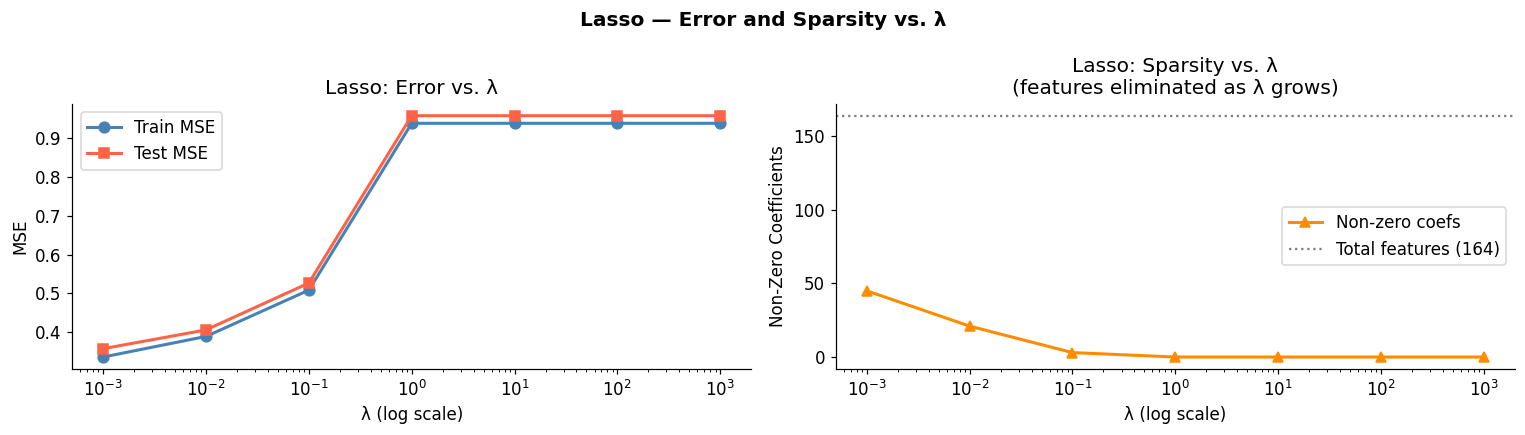

In [18]:
# ── F2: Lasso — error and sparsity vs λ ──────────────────────────────────────

lam_l  = list(lasso_results.keys())
te_l   = [lasso_results[l]['test_mse']  for l in lam_l]
tr_l   = [lasso_results[l]['train_mse'] for l in lam_l]
nz_l   = [lasso_results[l]['n_nonzero'] for l in lam_l]

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
fig.suptitle('Lasso — Error and Sparsity vs. λ', fontweight='bold')

axes[0].semilogx(lam_l, tr_l, 'o-', color='steelblue', lw=2, ms=7, label='Train MSE')
axes[0].semilogx(lam_l, te_l, 's-', color='tomato',    lw=2, ms=7, label='Test MSE')
axes[0].set(xlabel='λ (log scale)', ylabel='MSE', title='Lasso: Error vs. λ')
axes[0].legend()

axes[1].semilogx(lam_l, nz_l, '^-', color='darkorange', lw=2, ms=7, label='Non-zero coefs')
axes[1].axhline(X_tr_poly.shape[1], color='gray', ls=':', lw=1.5,
                label=f'Total features ({X_tr_poly.shape[1]})')
axes[1].set(xlabel='λ (log scale)', ylabel='Non-Zero Coefficients',
            title='Lasso: Sparsity vs. λ\n(features eliminated as λ grows)')
axes[1].legend()

plt.tight_layout()
plt.show()


In [19]:
# ── F3: LassoCV — auto-select λ ───────────────────────────────────────────────

lasso_cv = LassoCV(cv=5, max_iter=20000, random_state=42,
                   alphas=np.logspace(-4, 1, 60)).fit(X_tr_poly, y_tr)

best_lasso_alpha = lasso_cv.alpha_
y_pred_lcv       = lasso_cv.predict(X_te_poly)
lcv_te_mse       = mean_squared_error(y_te, y_pred_lcv)
lcv_te_r2        = r2_score(y_te, y_pred_lcv)
n_nonzero        = np.sum(lasso_cv.coef_ != 0)
n_zero           = np.sum(lasso_cv.coef_ == 0)
total_feats      = len(lasso_cv.coef_)

print(f"LassoCV — Best λ  : {best_lasso_alpha:.6f}")
print(f"          Test MSE : {lcv_te_mse:.4f}")
print(f"          Test R²  : {lcv_te_r2:.4f}")
print(f"          Non-zero : {n_nonzero} / {total_feats}  features kept")
print(f"          Zeroed   : {n_zero} / {total_feats}  ({100*n_zero/total_feats:.1f}% eliminated)")


LassoCV — Best λ  : 0.004954
          Test MSE : 0.3911
          Test R²  : 0.5921
          Non-zero : 24 / 164  features kept
          Zeroed   : 140 / 164  (85.4% eliminated)


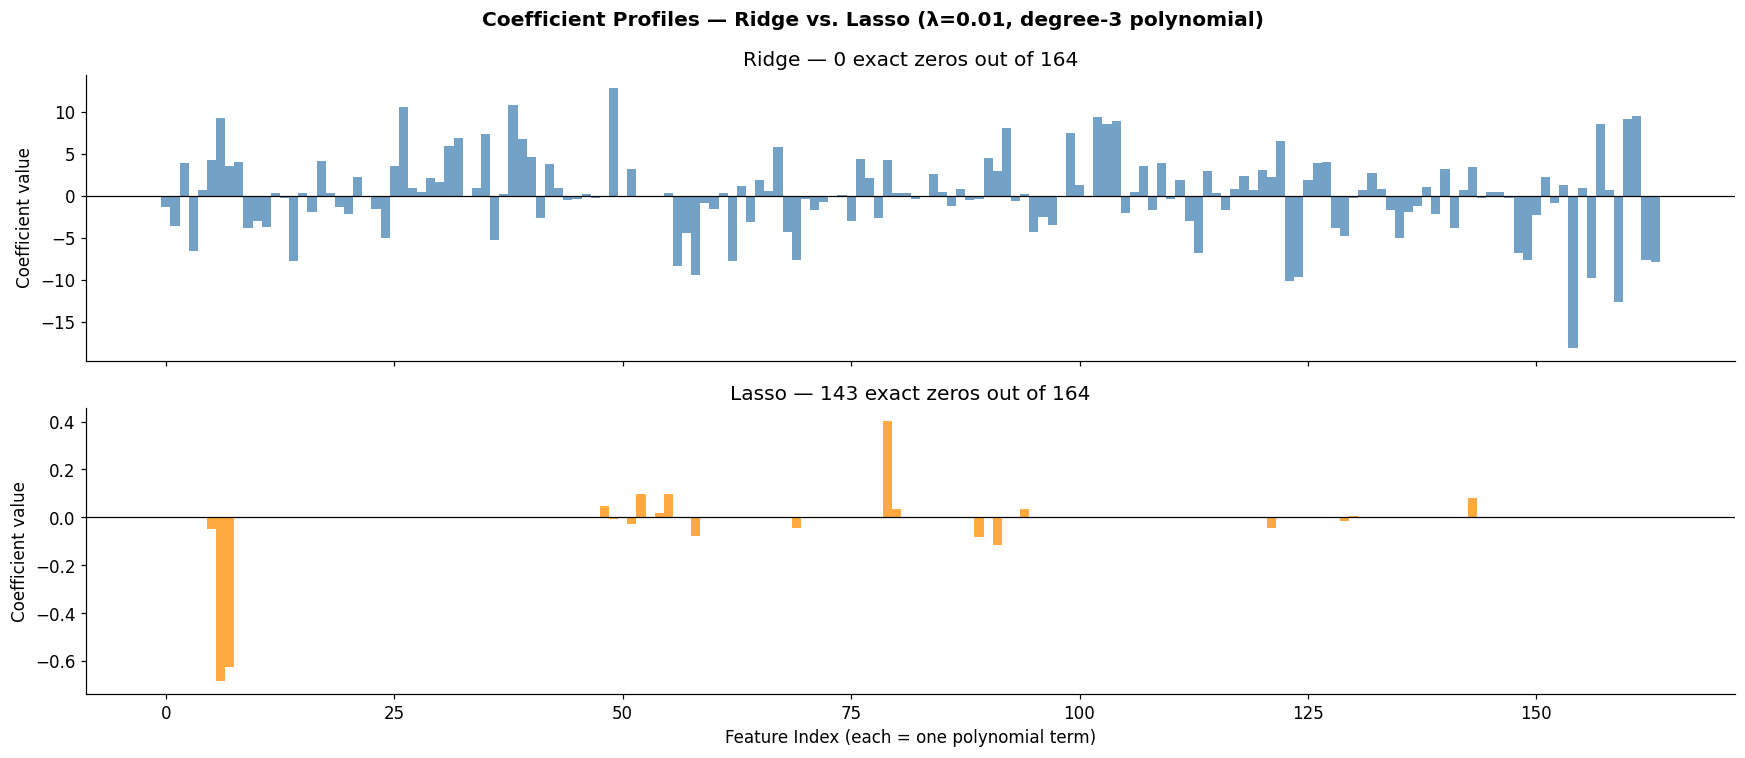


Ridge: all bars visible, none exactly at zero — shrinkage without elimination
Lasso: large blocks of bars at exactly zero — sparse, only key terms survive


In [20]:
# ── F4: Ridge vs. Lasso coefficient profiles ──────────────────────────────────

lam_show    = 0.01
ridge_coef  = Ridge(alpha=lam_show).fit(X_tr_poly, y_tr).coef_
lasso_coef  = Lasso(alpha=lam_show, max_iter=20000).fit(X_tr_poly, y_tr).coef_

fig, axes = plt.subplots(2, 1, figsize=(16, 7), sharex=True)
fig.suptitle(f'Coefficient Profiles — Ridge vs. Lasso (λ={lam_show}, degree-3 polynomial)',
             fontweight='bold')

feat_idx = np.arange(len(ridge_coef))
for ax, coef, title, color in zip(
    axes,
    [ridge_coef, lasso_coef],
    [f'Ridge — {np.sum(ridge_coef==0)} exact zeros out of {len(ridge_coef)}',
     f'Lasso — {np.sum(lasso_coef==0)} exact zeros out of {len(lasso_coef)}'],
    ['steelblue', 'darkorange']
):
    ax.bar(feat_idx, coef, color=color, alpha=0.75, edgecolor='none', width=1.0)
    ax.axhline(0, color='black', lw=0.8)
    ax.set(ylabel='Coefficient value', title=title)

axes[1].set_xlabel('Feature Index (each = one polynomial term)')
plt.tight_layout()
plt.show()

print()
print("Ridge: all bars visible, none exactly at zero — shrinkage without elimination")
print("Lasso: large blocks of bars at exactly zero — sparse, only key terms survive")


In [21]:
# ── F5: Full model comparison table ──────────────────────────────────────────

rows = []
rows.append({'Method': 'Linear Regression (d=1)', 'Best λ': 'N/A',
             'Train MSE': round(poly_results[1]['train_mse'], 4),
             'Test MSE':  round(poly_results[1]['test_mse'],  4),
             'Test R²':   round(poly_results[1]['test_r2'],   4),
             'Features':  poly_results[1]['n_features'], 'Notes': 'Baseline — underfits'})

for d in [2, 3, 4]:
    r = poly_results[d]
    rows.append({'Method': f'OLS Polynomial (d={d})', 'Best λ': 'N/A',
                 'Train MSE': round(r['train_mse'], 4),
                 'Test MSE':  round(r['test_mse'],  4),
                 'Test R²':   round(r['test_r2'],   4),
                 'Features':  r['n_features'],
                 'Notes': 'Overfits from d=3+'})

rows.append({'Method': 'Ridge (d=3, CV)', 'Best λ': round(best_alpha, 4),
             'Train MSE': round(mean_squared_error(y_tr, ridge_cv.predict(X_tr_poly)), 4),
             'Test MSE':  round(rcv_te_mse, 4), 'Test R²': round(rcv_te_r2, 4),
             'Features':  X_tr_poly.shape[1], 'Notes': 'All features, shrunk'})

rows.append({'Method': 'Lasso (d=3, CV)', 'Best λ': round(best_lasso_alpha, 5),
             'Train MSE': round(mean_squared_error(y_tr, lasso_cv.predict(X_tr_poly)), 4),
             'Test MSE':  round(lcv_te_mse, 4), 'Test R²': round(lcv_te_r2, 4),
             'Features':  f'{n_nonzero}/{total_feats}', 'Notes': f'{n_zero} features zeroed'})

df_compare = pd.DataFrame(rows)
print(df_compare.to_string(index=False))


                 Method     Best λ  Train MSE  Test MSE   Test R² Features                Notes
Linear Regression (d=1)        N/A     0.3985    0.4133    0.5689        8 Baseline — underfits
   OLS Polynomial (d=2)        N/A     0.3230    0.3590    0.6255       44   Overfits from d=3+
   OLS Polynomial (d=3)        N/A     0.2753    1.2081   -0.2601      164   Overfits from d=3+
   OLS Polynomial (d=4)        N/A     0.2298  341.1280 -354.8132      494   Overfits from d=3+
        Ridge (d=3, CV)  2940.0481     0.3947    0.4135    0.5687      164 All features, shrunk
        Lasso (d=3, CV)    0.00495     0.3755    0.3911    0.5921   24/164  140 features zeroed


#### 📝 Part F — Conceptual Questions

**Q10.** From the coefficient profile plots:  
Ridge and Lasso both use λ = 0.01, yet their profiles look very different.  
What specific geometric reason causes Lasso to produce exact zeros while Ridge does not?


**A10.** the specific geometric reason that causes Lasso to produce exact zeros while Ridge does not is due to the shape of the constraint regions defined by their respective penalty terms. Lasso uses an L1 penalty, which creates a diamond-shaped constraint region, while Ridge uses an L2 penalty, which creates a circular constraint region. The diamond shape of the L1 constraint can touch the contours of the loss function at the axes, leading to some coefficients being exactly zero. In contrast, the circular shape of the L2 constraint is less likely to touch the axes, so it does not produce exact zeros.

**Q11.** Look at the sparsity plot: Lasso zeroes out a large fraction of the 165 features. In the context of deploying this house price model at PriceSage, give two concrete reasons why a sparse model might be preferred over a dense one, even if their test MSE values are nearly equal.


**A11.** Two concrete reasons why a sparse model might be preferred over a dense one in the context of deploying a house price model at PriceSage are:

1. **Interpretability**: A sparse model with fewer features is easier to interpret and understand. Real estate agents may prefer a model that highlights the most important factors influencing house prices, rather than a dense model that includes many features with small coefficients. This can help agents make more informed decisions and provide better explanations to their clients.

2. **Computational Efficiency**: A sparse model with fewer features can be more computationally efficient to train and deploy. It requires less memory and processing power, which can lead to faster predictions and lower costs when the model is used in production. This is especially important if the model needs to make real-time predictions for a large number of listings.

---
## Final Reflection

**Reflection 1 — The Progressive Story**

Summarise the arc of this notebook in your own words:  
What went wrong at each step, and what fix did you apply?  
Use the learning curve plots to anchor your answer.


**answer:**

The notebook follows a clear failure-and-fix sequence. We started with linear regression which produced similar train/test scores but residual structure indicating underfitting (high bias). We then increased complexity with polynomial features; training error fell but the train-validation gap widened showing high variance and overfitting. Learning curves made this diagnosis explicit: degree-1 had high converged errors (bias problem) while degree-3 had a larger gap (variance problem). We then applied Ridge to keep nonlinear features but constrain coefficient magnitude. This reduced variance narrowed the learning-curve gap and improved generalisation. Finally Lasso provided a similarly regularised model with feature elimination making the solution more deployable and interpretable.

**Reflection 2 — Ridge vs. Lasso: Your Recommendation**

Ridge and Lasso both improved generalisation over unregularised OLS.
Discuss how their different penalty structures (L2 vs L1) influence:  
(a) variance reduction  
(b) coefficient stability under correlated features  
(c) interpretability


**answer:**

Ridge (L2) and Lasso (L1) both improve generalisation by regularising large coefficients but they do so differently. For variance reduction both help though Ridge often gives smoother shrinkage across all features and is very stable when predictors are correlated. Under multicollinearity Ridge tends to distribute weight across correlated terms producing stable dense solutions. Lasso in contrast tends to keep one/few terms and zero out others which can be less stable under strong correlation but yields sparse models. For interpretability Lasso is usually superior because exact zeros perform implicit feature selection and make explanations easier. My deployment recommendation is: choose Ridge when predictive stability under correlated engineered terms is primary; choose Lasso when near-equal accuracy is achieved and simplicity/interpretability are high priority.

In [22]:
# ── Final auto-populated summary ──────────────────────────────────────────────
print("=" * 70)
print("  PAGESAGE MODEL SELECTION — FINAL SUMMARY")
print("=" * 70)
print()
print(df_compare.to_string(index=False))
print()

# Find the best row based on the lowest Test MSE
best_row = df_compare.loc[df_compare['Test MSE'].idxmin()]

print(f"Winning model   : {best_row['Method']}")
print(f"Test MSE        : {best_row['Test MSE']}")
print(f"Test R²         : {best_row['Test R²']}")
print(f"Ridge best λ    : {best_alpha:.5f}  (found via 5-fold CV)")
print(f"Lasso best λ    : {best_lasso_alpha:.6f}  (found via 5-fold CV)")
print(f"Lasso sparsity  : {n_zero}/{total_feats} features eliminated ({100*n_zero/total_feats:.1f}%)")
print("=" * 70)

  PAGESAGE MODEL SELECTION — FINAL SUMMARY

                 Method     Best λ  Train MSE  Test MSE   Test R² Features                Notes
Linear Regression (d=1)        N/A     0.3985    0.4133    0.5689        8 Baseline — underfits
   OLS Polynomial (d=2)        N/A     0.3230    0.3590    0.6255       44   Overfits from d=3+
   OLS Polynomial (d=3)        N/A     0.2753    1.2081   -0.2601      164   Overfits from d=3+
   OLS Polynomial (d=4)        N/A     0.2298  341.1280 -354.8132      494   Overfits from d=3+
        Ridge (d=3, CV)  2940.0481     0.3947    0.4135    0.5687      164 All features, shrunk
        Lasso (d=3, CV)    0.00495     0.3755    0.3911    0.5921   24/164  140 features zeroed

Winning model   : OLS Polynomial (d=2)
Test MSE        : 0.359
Test R²         : 0.6255
Ridge best λ    : 2940.04806  (found via 5-fold CV)
Lasso best λ    : 0.004954  (found via 5-fold CV)
Lasso sparsity  : 140/164 features eliminated (85.4%)
